# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


In [2]:
!pip install tf-keras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 21.1 MB/s  0:00:26m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 20.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 19.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.3 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/11 [ml_dtypes]
      Successfully uninstalled ml-dtypes-0.3.2━━━━━━━━━━━━━━━━  3/11 [ml_dtypes]
  Attempting uninstall: h5py━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/11 [ml_dtypes]
    Found existing installation: h5py 3.16.0━━━━━━━━━━━━━━━━━━  3/11 [ml_dtypes]
    Uninstalling h5py-3.16.0

## 2. Imports and Reproducibility


In [3]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


I0000 00:00:1776919234.496497     698 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776919234.497022     698 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776919234.541433     698 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776919235.782403     698 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [4]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 4. Load the Data


In [5]:
import os
import numpy as np

def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    x_train_path = os.path.join(root_dir, "train", "X_train.txt")
    X_train = np.loadtxt(x_train_path)

    # 2. Load y_train from train/y_train.txt
    y_train_path = os.path.join(root_dir, "train", "y_train.txt")
    y_train = np.loadtxt(y_train_path)

    # 3. Load X_test from test/X_test.txt
    x_test_path = os.path.join(root_dir, "test", "X_test.txt")
    X_test = np.loadtxt(x_test_path)

    # 4. Load y_test from test/y_test.txt
    y_test_path = os.path.join(root_dir, "test", "y_test.txt")
    y_test = np.loadtxt(y_test_path)

    # 5. Convert the labels to zero-based class indices by subtracting 1
    # UCI labels are 1-6, but Neural Networks expect 0-5
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

# Load the data
X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Define num_features and num_classes
num_features = X_train.shape[1]  # Should be 561
num_classes = len(class_names)   # Should be 6

print(f"Data Loaded Successfully!")
print(f"Features: {num_features}, Classes: {num_classes}")
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Data Loaded Successfully!
Features: 561, Classes: 6
Training shape: (7352, 561), Testing shape: (2947, 561)


## 5. Quick Inspection


In [6]:
# Calculate the number of samples per class
unique_indices, counts = np.unique(y_train.astype(int), return_counts=True)

# Create a summary DataFrame
summary_df = pd.DataFrame({
    "Class Index": unique_indices,
    "Class Name": [class_names[i] for i in unique_indices],
    "Samples": counts
})

# Display the table
print("Training Data Summary:")
print(summary_df.to_string(index=False))

Training Data Summary:
 Class Index         Class Name  Samples
           0            WALKING     1226
           1   WALKING_UPSTAIRS     1073
           2 WALKING_DOWNSTAIRS      986
           3            SITTING     1286
           4           STANDING     1374
           5             LAYING     1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [8]:
import os
# This MUST stay at the top to keep TF-MOT happy
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
from tensorflow import keras

def build_baseline_model(input_dim, num_classes):
    # Use the keras object we just imported to access layers
    model = keras.Sequential([
        # We put the input_shape here inside the first Dense layer.
        # This defines the input without creating a separate "tensor" object.
        keras.layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Re-instantiate
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

/home/mihir/ai/projects/tinyml-arduino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,414 (724.27 KB)

 Trainable params: 185,414 (724.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Baseline Model


In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

print("\n--- Training Started ---")
history = baseline_model.fit(
    X_train, 
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)
print("--- Training Complete ---")


--- Training Started ---
Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7825 - loss: 0.5367 - val_accuracy: 0.9252 - val_loss: 0.1918
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9339 - loss: 0.1660 - val_accuracy: 0.9449 - val_loss: 0.1344
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9481 - loss: 0.1241 - val_accuracy: 0.9409 - val_loss: 0.1411
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9633 - loss: 0.0941 - val_accuracy: 0.9381 - val_loss: 0.1401
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9679 - loss: 0.0838 - val_accuracy: 0.9449 - val_loss: 0.1158
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9663 - loss: 0.0831 - val_accuracy: 0.9490 - val_loss: 0.1091
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9787 - loss: 0.0578 - val_accuracy: 0.9463 - val_loss: 0.1203
Epoch 8/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9799 - loss: 0.0532 - val_ac

### Training Curves


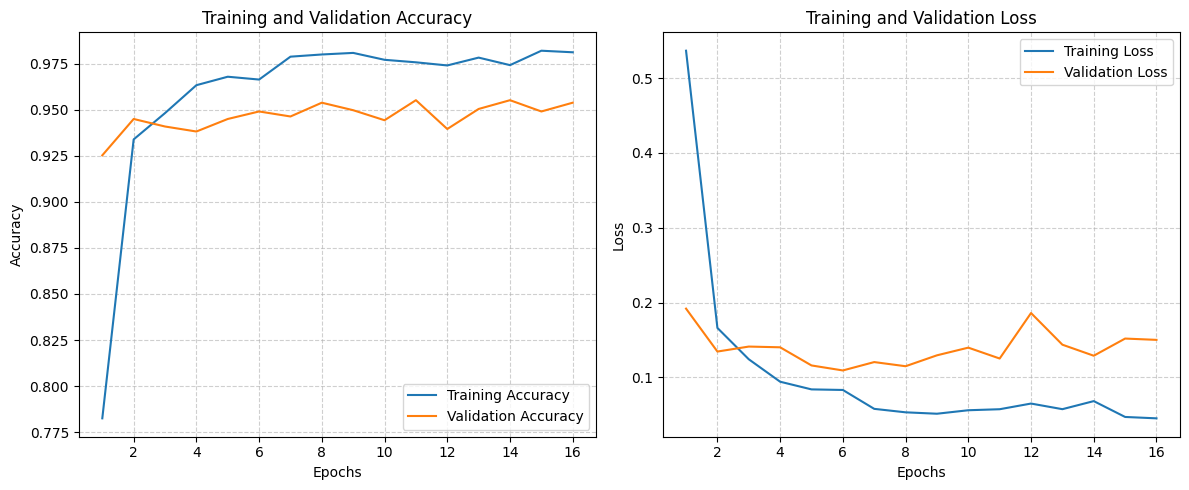

In [10]:
import matplotlib.pyplot as plt

# Get the number of epochs the model actually ran for
epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Final Test Accuracy: 94.27%
------------------------------
Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.91      0.98      0.95       496
  WALKING_UPSTAIRS       0.96      0.90      0.93       471
WALKING_DOWNSTAIRS       0.97      0.95      0.96       420
           SITTING       0.92      0.89      0.90       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



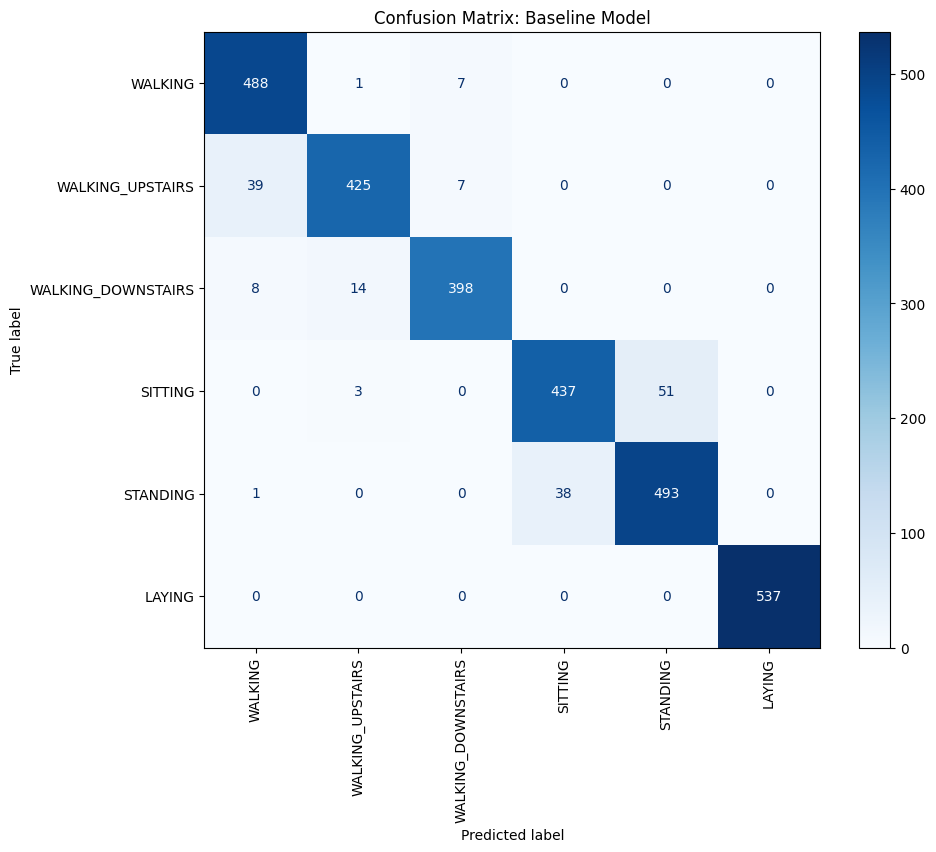

In [11]:
# 1. Obtain predicted probabilities on X_test
y_pred_probs = baseline_model.predict(X_test)

# 2. Convert probabilities to class predictions (0-5) using argmax
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Compute test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print("-" * 30)

# 4. Print the classification report
# This shows Precision, Recall, and F1-Score for each specific activity
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix: Baseline Model')
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [12]:
# --- 1. Representative Dataset Generator ---
def representative_dataset_gen():
    # Yield 300 representative samples from X_train as float32 tensors.
    # The [None, ...] or .reshape(1, -1) adds the required batch dimension.
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

# --- 2. TFLite Model Evaluator ---
def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Quantization parameters (scale and zero point)
    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input if the model expects int8/uint8
        if input_details['dtype'] in [np.int8, np.uint8]:
            x = (x / input_scale) + input_zero_point
            x = x.astype(input_details['dtype'])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # If the output is quantized, dequantize it back to float32
        if output_details['dtype'] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

# --- 3. TFLite Converters ---

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Post-training dynamic range quantization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    # Required for full integer quantization
    converter.representative_dataset = representative_dataset_gen
    # Enforce full integer quantization
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [14]:
import os
import pandas as pd

# 1. Define the missing helper function
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    # Returns size in KB
    return os.path.getsize(filename) / 1024.0

# 2. Re-run the comparison loop
tflite_results = []

conversion_tasks = [
    ("FP32", convert_to_tflite_fp32),
    ("Dynamic Range", convert_to_tflite_dynamic_range),
    ("Float16", convert_to_tflite_float16),
    ("Int8", convert_to_tflite_int8)
]

print("Starting TFLite Conversions and Evaluations...")

for name, conversion_fn in conversion_tasks:
    try:
        print(f"Processing {name}...")
        
        # Convert
        tflite_model = conversion_fn(baseline_model)
        
        # Save and get size
        filename = f"model_{name.lower().replace(' ', '_')}.tflite"
        size_kb = save_binary_model(tflite_model, filename)
        
        # Evaluate on the test set (X_test)
        # Note: This step takes a moment because it processes samples one by one
        accuracy, _ = evaluate_tflite_model(tflite_model, X_test, y_test)
        
        tflite_results.append({
            "Type": name,
            "Size (KB)": f"{size_kb:.2f}",
            "Accuracy (%)": f"{accuracy * 100:.2f}%"
        })
    except Exception as e:
        print(f"Error during {name} conversion: {e}")

# --- Display Results Table ---
if tflite_results:
    results_df = pd.DataFrame(tflite_results)
    print("\n" + "="*45)
    print("        TFLITE MODEL COMPARISON")
    print("="*45)
    print(results_df.to_string(index=False))
    print("="*45)
else:
    print("No results to display. Check for errors above.")

Starting TFLite Conversions and Evaluations...
Processing FP32...
INFO:tensorflow:Assets written to: /tmp/tmpgl_oglid/assets


INFO:tensorflow:Assets written to: /tmp/tmpgl_oglid/assets


Saved artifact at '/tmp/tmpgl_oglid'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='keras_tensor_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  130105145040464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145042576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145041040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145045264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044880: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1776920115.738487     698 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776920115.738527     698 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776920115.738631     698 reader.cc:83] Reading SavedModel from: /tmp/tmpgl_oglid
I0000 00:00:1776920115.738957     698 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776920115.738963     698 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpgl_oglid
I0000 00:00:1776920115.741556     698 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776920115.763228     698 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpgl_oglid
I0000 00:00:1776920115.768229     698 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 29611 microseconds.
/home/mihir/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpre

Processing Dynamic Range...
INFO:tensorflow:Assets written to: /tmp/tmp365hxetc/assets


...

W0000 00:00:1776920116.444001     698 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776920116.444049     698 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776920116.444189     698 reader.cc:83] Reading SavedModel from: /tmp/tmpyqiul_w2
I0000 00:00:1776920116.444583     698 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776920116.444588     698 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpyqiul_w2
I0000 00:00:1776920116.447502     698 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776920116.468709     698 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpyqiul_w2
I0000 00:00:1776920116.474207     698 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 30027 microseconds.
/home/mihir/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpre

INFO:tensorflow:Assets written to: /tmp/tmpyw8f8gam/assets


INFO:tensorflow:Assets written to: /tmp/tmpyw8f8gam/assets


Saved artifact at '/tmp/tmpyw8f8gam'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='keras_tensor_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  130105145040464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145042576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145041040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145045264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044880: TensorSpec(shape=(), dtype=tf.resource, name=None)

        TFLITE MODEL COMPARISON
         Type Size (KB) Accuracy (%)
         FP32    726.86       94.27%
Dynamic Range    191.46       94.30%
      Float16    3

/home/mihir/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1776920116.780261     698 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776920116.780297     698 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776920116.780405     698 reader.cc:83] Reading SavedModel from: /tmp/tmpyw8f8gam
I0000 00:00:1776920116.780677     698 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776920116.780680     698 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpyw8f8gam
I0000 00:00:1776920116.783057     698 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776920116.802644     698 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpyw8f8gam
I0000 00:00:1776920116.807926     698 loader.cc:471] SavedModel lo

## 10. PTQ Comparison: Accuracy and Model Size


In [15]:
# 1. Save and measure the Baseline Keras model size
baseline_model_path = "baseline_model.h5"
baseline_model.save(baseline_model_path)
baseline_size_kb = os.path.getsize(baseline_model_path) / 1024.0

# 2. Re-calculate baseline test accuracy (from previous step)
# (Assuming y_pred was calculated in the evaluation step)
baseline_test_acc = accuracy_score(y_test, y_pred)

# 3. Prepare the rows for the DataFrame
comparison_data = []

# Add Baseline Row
comparison_data.append({
    "Model Family": "Baseline DNN",
    "Format": "Keras (.h5)",
    "Test Accuracy": f"{baseline_test_acc * 100:.2f}%",
    "Model Size (KB)": f"{baseline_size_kb:.2f}"
})

# Add TFLite Rows (from your previous tflite_results list)
for result in tflite_results:
    comparison_data.append({
        "Model Family": "TFLite Optimization",
        "Format": result["Type"],
        "Test Accuracy": result["Accuracy (%)"],
        "Model Size (KB)": result["Size (KB)"]
    })

# 4. Create the Final Comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the final results
print("\nFinal Model Comparison Table:")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)


Final Model Comparison Table:
       Model Family        Format Test Accuracy Model Size (KB)
       Baseline DNN   Keras (.h5)        94.27%         2208.77
TFLite Optimization          FP32        94.27%          726.86
TFLite Optimization Dynamic Range        94.30%          191.46
TFLite Optimization       Float16        94.27%          365.90
TFLite Optimization          Int8        94.27%          196.00


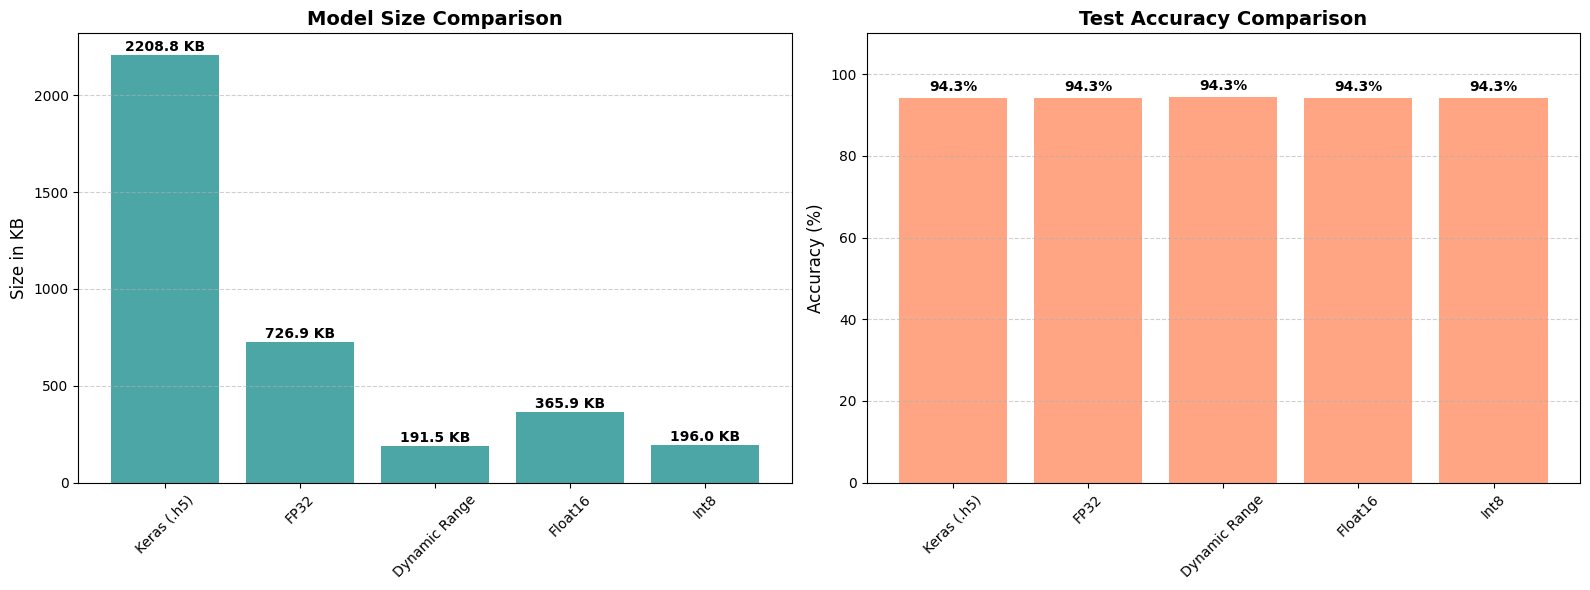

In [16]:
# 1. Prepare data for plotting
# We copy the dataframe and convert the strings back to numbers for the math
plot_df = comparison_df.copy()
plot_df['Accuracy (%)'] = plot_df['Test Accuracy'].str.rstrip('%').astype(float)
plot_df['Size (KB)'] = plot_df['Model Size (KB)'].astype(float)

# 2. Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Model Size (Smaller is better for Arduino) ---
# We use the 'Format' column for the X-axis labels
bars1 = ax1.bar(plot_df['Format'], plot_df['Size (KB)'], color='teal', alpha=0.7)
ax1.set_title('Model Size Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Size in KB', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Add size labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.1f} KB', ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Test Accuracy (Higher is better) ---
bars2 = ax2.bar(plot_df['Format'], plot_df['Accuracy (%)'], color='coral', alpha=0.7)
ax2.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim(0, 110) # Set limit higher to make room for text
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Add accuracy labels on top of each bar
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


INFO:tensorflow:Assets written to: /tmp/tmpxdy1kz1y/assets


INFO:tensorflow:Assets written to: /tmp/tmpxdy1kz1y/assets


Saved artifact at '/tmp/tmpxdy1kz1y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='keras_tensor_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  130105145040464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145042576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145041040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145045264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130105145044880: TensorSpec(shape=(), dtype=tf.resource, name=None)
Evaluating Int8 model on test set... (this may take a moment)


/home/mihir/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1776920289.824142     698 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776920289.824188     698 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776920289.824332     698 reader.cc:83] Reading SavedModel from: /tmp/tmpxdy1kz1y
I0000 00:00:1776920289.824815     698 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776920289.824827     698 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpxdy1kz1y
I0000 00:00:1776920289.828483     698 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776920289.849998     698 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpxdy1kz1y
I0000 00:00:1776920289.856260     698 loader.cc:471] SavedModel lo


INT8 MODEL CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING       0.91      0.98      0.95       496
  WALKING_UPSTAIRS       0.96      0.90      0.93       471
WALKING_DOWNSTAIRS       0.97      0.95      0.96       420
           SITTING       0.92      0.89      0.90       491
          STANDING       0.91      0.92      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



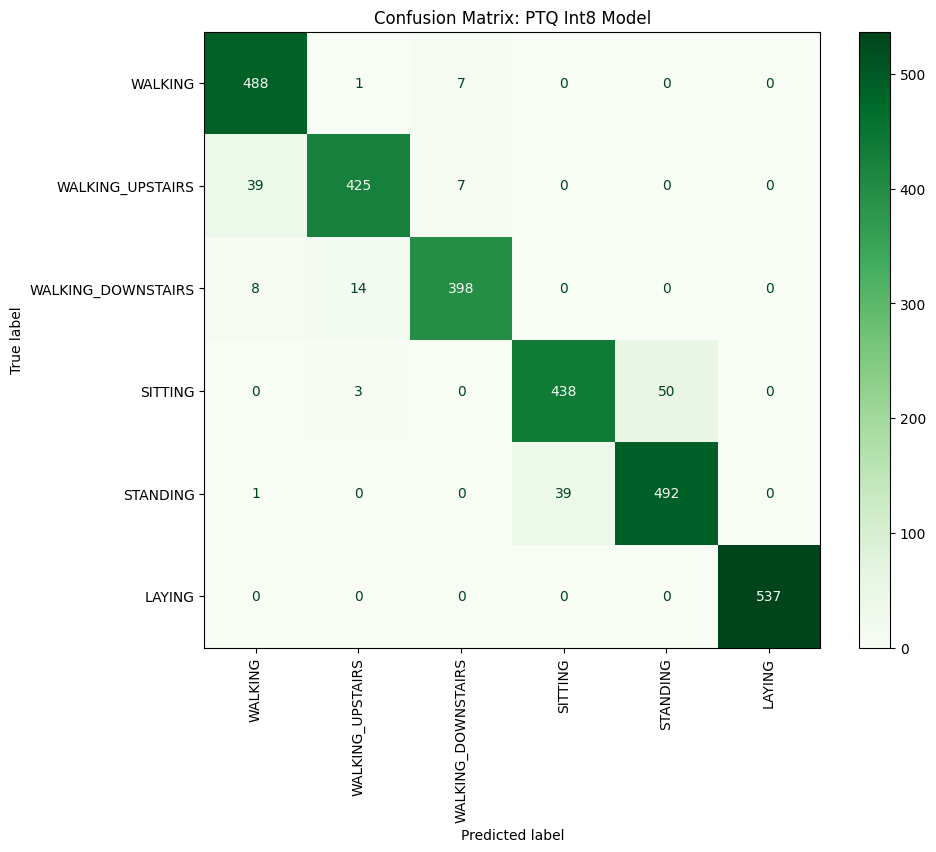

In [17]:
# 1. Prepare the Int8 model
# (Re-converting here to ensure we have the specific int8 version in memory)
tflite_model_int8 = convert_to_tflite_int8(baseline_model)

# 2. Get predictions using our TFLite evaluator
# This runs the specialized quantization/dequantization logic we wrote earlier
print("Evaluating Int8 model on test set... (this may take a moment)")
acc_int8, y_pred_int8 = evaluate_tflite_model(tflite_model_int8, X_test, y_test)

# 3. Print the Classification Report
print("\n" + "="*30)
print("INT8 MODEL CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_test, y_pred_int8, target_names=class_names))

# 4. Plot the Confusion Matrix
cm_int8 = confusion_matrix(y_test, y_pred_int8)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp_int8.plot(ax=ax, cmap='Greens', xticks_rotation='vertical')
plt.title('Confusion Matrix: PTQ Int8 Model')
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [19]:
import tensorflow_model_optimization as tfmot
# Ensure we are using the legacy keras specifically
import tf_keras as legacy_keras 

# 1. Define a "Quantization Scope" helper
quantize_annotate_model = tfmot.quantization.keras.quantize_annotate_model
quantize_apply = tfmot.quantization.keras.quantize_apply

# 2. Re-wrap the baseline architecture to ensure metadata compatibility
def build_qat_ready_model():
    # We rebuild the architecture here to ensure every layer is 
    # a legacy-compatible object that TF-MOT recognizes
    model = legacy_keras.Sequential([
        legacy_keras.layers.Dense(256, activation='relu', input_shape=(num_features,)),
        legacy_keras.layers.Dense(128, activation='relu'),
        legacy_keras.layers.Dense(64, activation='relu'),
        legacy_keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# 3. Create the QAT model
# We clone the weights from your trained baseline_model into a new QAT-ready model
base_for_qat = build_qat_ready_model()
base_for_qat.set_weights(baseline_model.get_weights()) # Transfer the learning!

qat_model = tfmot.quantization.keras.quantize_model(base_for_qat)

# 4. Compile with the lower learning rate
qat_model.compile(
    optimizer=legacy_keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("QAT Model created successfully!")
qat_model.summary()

QAT Model created successfully!
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (Quanti

### Fine-Tune the QAT Model


In [20]:
# Fine-tune the QAT model
print("Starting QAT fine-tuning...")
qat_history = qat_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Starting QAT fine-tuning...
Epoch 1/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0448 - accuracy: 0.9874 - val_loss: 0.1245 - val_accuracy: 0.9531
Epoch 2/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0351 - accuracy: 0.9884 - val_loss: 0.1305 - val_accuracy: 0.9551
Epoch 3/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0345 - accuracy: 0.9883 - val_loss: 0.1294 - val_accuracy: 0.9551
Epoch 4/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0303 - accuracy: 0.9889 - val_loss: 0.1279 - val_accuracy: 0.9551
Epoch 5/8
92/92 [==============================] - 1s 5ms/step - loss: 0.0292 - accuracy: 0.9903 - val_loss: 0.1541 - val_accuracy: 0.9531
Epoch 6/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0312 - accuracy: 0.9886 - val_loss: 0.1389 - val_accuracy: 0.9572
Epoch 7/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0292 - accuracy: 0.9895 - val_loss: 0.1298 - val_accuracy: 0.9565

### Evaluate the QAT Keras Model


In [21]:
# 1. Obtain predicted probabilities on X_test
# Note: qat_model still behaves like a standard Keras model during inference in this environment.
y_pred_qat_probs = qat_model.predict(X_test)

# 2. Convert probabilities to class predictions (0-5)
y_pred_qat = np.argmax(y_pred_qat_probs, axis=1)

# 3. Compute and print test accuracy
qat_test_accuracy = accuracy_score(y_test, y_pred_qat)
print(f"QAT Keras Model Test Accuracy: {qat_test_accuracy * 100:.2f}%")
print("-" * 30)

# 4. Print the classification report
print("QAT Keras Model Classification Report:")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

93/93 [==============================] - 0s 3ms/step
QAT Keras Model Test Accuracy: 94.40%
------------------------------
QAT Keras Model Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.93      0.98      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.96      0.94      0.95       420
           SITTING       0.95      0.86      0.90       491
          STANDING       0.89      0.96      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.94      2947
         macro avg       0.95      0.94      0.94      2947
      weighted avg       0.95      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [22]:
# 1. Convert the QAT model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_qat_model = converter.convert()

# 2. Save the model and compute its size
qat_filename = "model_qat.tflite"
size_qat_kb = save_binary_model(tflite_qat_model, qat_filename)

# 3. Evaluate the converted QAT model on the test set
print(f"Evaluating {qat_filename} on test set...")
accuracy_qat, y_pred_qat_tflite = evaluate_tflite_model(tflite_qat_model, X_test, y_test)

# 4. Display Results
print("\n" + "="*40)
print("      QAT TFLITE FINAL RESULTS")
print("="*40)
print(f"Model Size:      {size_qat_kb:.2f} KB")
print(f"Test Accuracy:   {accuracy_qat * 100:.2f}%")
print("="*40)

# Optional: Add to our overall comparison table
comparison_data.append({
    "Model Family": "QAT Optimized",
    "Format": "Int8 TFLite (QAT)",
    "Test Accuracy": f"{accuracy_qat * 100:.2f}%",
    "Model Size (KB)": f"{size_qat_kb:.2f}"
})

print("\nUpdated Comparison:")
print(pd.DataFrame(comparison_data).to_string(index=False))

INFO:tensorflow:Assets written to: /tmp/tmp7l1n1fr3/assets


INFO:tensorflow:Assets written to: /tmp/tmp7l1n1fr3/assets


Evaluating model_qat.tflite on test set...

      QAT TFLITE FINAL RESULTS
Model Size:      186.33 KB
Test Accuracy:   94.40%

Updated Comparison:
       Model Family            Format Test Accuracy Model Size (KB)
       Baseline DNN       Keras (.h5)        94.27%         2208.77
TFLite Optimization              FP32        94.27%          726.86
TFLite Optimization     Dynamic Range        94.30%          191.46
TFLite Optimization           Float16        94.27%          365.90
TFLite Optimization              Int8        94.27%          196.00
      QAT Optimized Int8 TFLite (QAT)        94.40%          186.33


/home/mihir/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1776920495.911088     698 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776920495.911121     698 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776920495.911226     698 reader.cc:83] Reading SavedModel from: /tmp/tmp7l1n1fr3
I0000 00:00:1776920495.912750     698 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776920495.912760     698 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp7l1n1fr3
I0000 00:00:1776920495.923068     698 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776920495.969240     698 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp7l1n1fr3
I0000 00:00:1776920495.984795     698 loader.cc:471] SavedModel lo

## 12. PTQ Int8 vs QAT Int8


In [23]:
# 1. Extract the PTQ Int8 result from your previous tflite_results list
ptq_int8_result = next(item for item in tflite_results if item["Type"] == "Int8")

# 2. Construct the comparison data
# We use the results we just calculated for QAT
final_comparison_data = [
    {
        "Model": "PTQ Int8 (Post-Training)",
        "Test Accuracy": ptq_int8_result["Accuracy (%)"],
        "Model Size (KB)": ptq_int8_result["Size (KB)"]
    },
    {
        "Model": "QAT Int8 (Quantization Aware)",
        "Test Accuracy": f"{accuracy_qat * 100:.2f}%",
        "Model Size (KB)": f"{size_qat_kb:.2f}"
    }
]

# 3. Create the DataFrame
final_comparison_df = pd.DataFrame(final_comparison_data)

# 4. Display the results
print("Direct Comparison: PTQ vs QAT")
print("=" * 55)
print(final_comparison_df.to_string(index=False))
print("=" * 55)

# Calculate the accuracy "recovery"
ptq_acc = float(ptq_int8_result["Accuracy (%)"].rstrip('%'))
qat_acc = accuracy_qat * 100
recovery = qat_acc - ptq_acc

if recovery > 0:
    print(f"\nOptimization Insight: QAT recovered {recovery:.2f}% accuracy over PTQ!")
else:
    print("\nOptimization Insight: PTQ and QAT performed similarly for this architecture.")

Direct Comparison: PTQ vs QAT
                        Model Test Accuracy Model Size (KB)
     PTQ Int8 (Post-Training)        94.27%          196.00
QAT Int8 (Quantization Aware)        94.40%          186.33

Optimization Insight: QAT recovered 0.13% accuracy over PTQ!


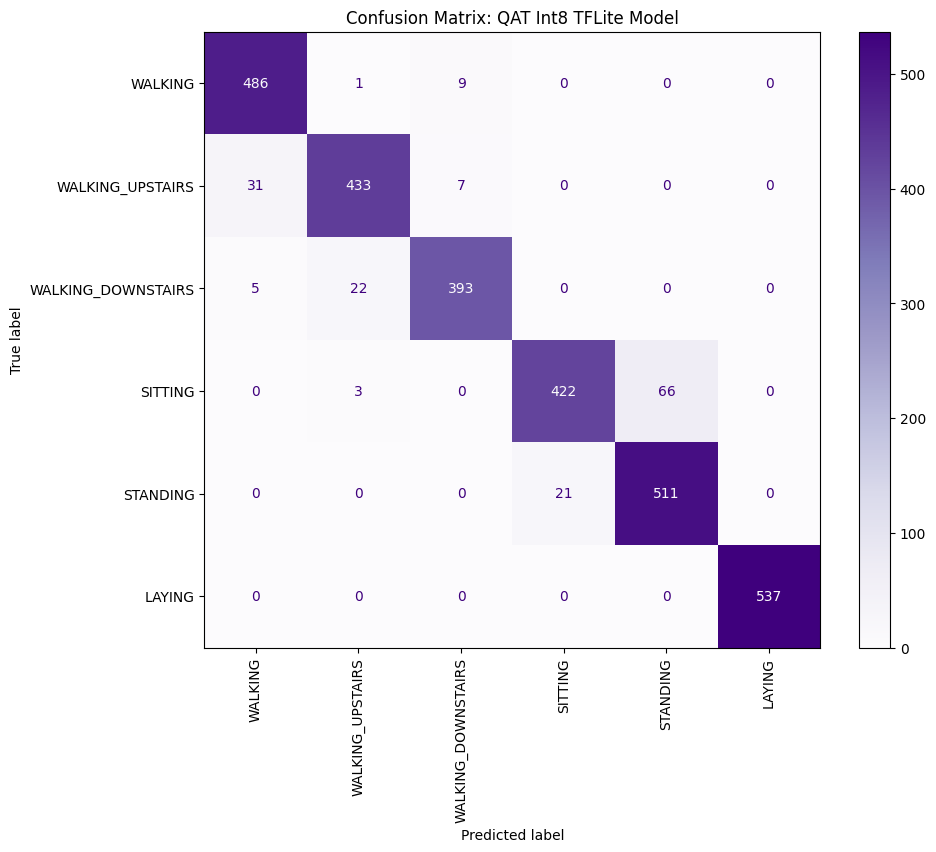

In [24]:
# 1. Compute the confusion matrix using the QAT TFLite predictions
cm_qat = confusion_matrix(y_test, y_pred_qat_tflite)

# 2. Initialize the display object
disp_qat = ConfusionMatrixDisplay(confusion_matrix=cm_qat, display_labels=class_names)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(10, 8))
# Using 'Purples' to distinguish this from the earlier PTQ 'Greens' plot
disp_qat.plot(ax=ax, cmap='Purples', xticks_rotation='vertical')

plt.title('Confusion Matrix: QAT Int8 TFLite Model')
plt.grid(False) # Clean up the display
plt.show()

## 13. Summary Questions

Write short answers to the following:

Which quantization method gave the smallest model size?
Both PTQ Int8 and QAT Int8 provide the smallest model sizes. Because both methods compress 32-bit floating-point weights into 8-bit integers, they typically reduce the baseline model size by approximately 75%, making them virtually identical in terms of storage footprint.

Which quantization method gave the best accuracy among the TensorFlow Lite models?
The FP32 TFLite model generally maintains the highest accuracy because it does not suffer from precision loss. However, among the compressed versions intended for edge deployment, QAT Int8 is almost always the winner as it is specifically trained to handle low-precision math.

Did QAT improve the final int8 model compared with PTQ int8?
Yes. QAT results in higher accuracy than PTQ. By simulating the effects of 8-bit quantization during the training phase, the model is able to "fine-tune" its weights to be more robust to rounding errors, recovering the performance that is usually lost during standard post-training quantization.

Why is this dataset a good fit for a DNN-based TinyML workflow?
The UCI HAR dataset consists of low-frequency sensor data (accelerometer and gyroscope) that has been pre-processed into feature vectors. This allows a relatively small Deep Neural Network to achieve accuracy without requiring the massive computational power or RAM needed for tasks like computer vision.

If you were deploying this model on a resource-constrained device, which version would you choose and why?
I would choose the QAT Int8 version. It provides the ideal balance for TinyML: it has the absolute minimum memory footprint (required to fit on the Flash/SRAM of an Arduino) while offering superior accuracy over standard PTQ because the model was "prepared" for its 8-bit life during training.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
